# Section 1 – Turning clinical text into numbers

## Part 1 – Cleaning the text and building Bag-of-Words and TF-IDF representations

### Q1 – Writing a function that removes stop words

In [1]:
import spacy

nlp = spacy.load("en_core_web_sm")

def remove_stopword(text):
    doc = nlp(text)
    filtered_words = [token.text for token in doc if not token.is_stop]
    return filtered_words

remove_stopword("The researchers are developing advanced algorithms.")
remove_stopword("i am feeling grouchy")

['feeling', 'grouchy']

### Q2 – Removing the stop words from every sentence of the dataset

In [2]:
import pandas as pd

data = pd.DataFrame(data=[["i didnt feel humiliated",
0],["i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and ...",
0],["im grabbing a minute to post i feel greedy wrong",3],["i am ever feeling nostalgic about the fireplace i will know that it is still on the property",
2],["i am feeling grouchy",
3],["ive been feeling a little burdened lately wasnt sure why that was",
0],["ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i a...",
5],["i feel as confused about life as a teenager or as jaded as a year old man",
4]], columns=["text", "label"])

In [3]:
print(data.head())

                                                text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3


In [4]:
data["stop_word"] = data["text"].apply(remove_stopword)
data

,text,label,stop_word
0,i didnt feel humiliated,0,"[nt, feel, humiliated]"
1,i can go from feeling so hopeless to so damned...,0,"[feeling, hopeless, damned, hopeful, cares, ...]"
2,im grabbing a minute to post i feel greedy wrong,3,"[m, grabbing, minute, post, feel, greedy, wrong]"
3,i am ever feeling nostalgic about the fireplac...,2,"[feeling, nostalgic, fireplace, know, property]"
4,i am feeling grouchy,3,"[feeling, grouchy]"
5,ive been feeling a little burdened lately wasn...,0,"[ve, feeling, little, burdened, lately, nt, sure]"
6,ive been taking or milligrams or times recomme...,5,"[ve, taking, milligrams, times, recommended, v..."
7,i feel as confused about life as a teenager or...,4,"[feel, confused, life, teenager, jaded, year, ..."


In [5]:
data["text_clean"] = data["stop_word"].apply(lambda x: " ".join(x))
data

,text,label,stop_word,text_clean
0,i didnt feel humiliated,0,"[nt, feel, humiliated]",nt feel humiliated
1,i can go from feeling so hopeless to so damned...,0,"[feeling, hopeless, damned, hopeful, cares, ...]",feeling hopeless damned hopeful cares ...
2,im grabbing a minute to post i feel greedy wrong,3,"[m, grabbing, minute, post, feel, greedy, wrong]",m grabbing minute post feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,2,"[feeling, nostalgic, fireplace, know, property]",feeling nostalgic fireplace know property
4,i am feeling grouchy,3,"[feeling, grouchy]",feeling grouchy
5,ive been feeling a little burdened lately wasn...,0,"[ve, feeling, little, burdened, lately, nt, sure]",ve feeling little burdened lately nt sure
6,ive been taking or milligrams or times recomme...,5,"[ve, taking, milligrams, times, recommended, v...",ve taking milligrams times recommended ve fall...
7,i feel as confused about life as a teenager or...,4,"[feel, confused, life, teenager, jaded, year, ...",feel confused life teenager jaded year old man


### Q3 – Counting how often each word appears in a sentence

In [6]:
def count_words(sentence):
    counts = {}
    for word in sentence.lower().split():
        counts[word] = counts.get(word, 0) + 1
    return counts

count_words("the doctor received the patients")

{'the': 2, 'doctor': 1, 'received': 1, 'patients': 1}

In [7]:
data["occurrence"] = data["text_clean"].apply(count_words)
data

,text,label,stop_word,text_clean,occurrence
0,i didnt feel humiliated,0,"[nt, feel, humiliated]",nt feel humiliated,"{'nt': 1, 'feel': 1, 'humiliated': 1}"
1,i can go from feeling so hopeless to so damned...,0,"[feeling, hopeless, damned, hopeful, cares, ...]",feeling hopeless damned hopeful cares ...,"{'feeling': 1, 'hopeless': 1, 'damned': 1, 'ho..."
2,im grabbing a minute to post i feel greedy wrong,3,"[m, grabbing, minute, post, feel, greedy, wrong]",m grabbing minute post feel greedy wrong,"{'m': 1, 'grabbing': 1, 'minute': 1, 'post': 1..."
3,i am ever feeling nostalgic about the fireplac...,2,"[feeling, nostalgic, fireplace, know, property]",feeling nostalgic fireplace know property,"{'feeling': 1, 'nostalgic': 1, 'fireplace': 1,..."
4,i am feeling grouchy,3,"[feeling, grouchy]",feeling grouchy,"{'feeling': 1, 'grouchy': 1}"
5,ive been feeling a little burdened lately wasn...,0,"[ve, feeling, little, burdened, lately, nt, sure]",ve feeling little burdened lately nt sure,"{'ve': 1, 'feeling': 1, 'little': 1, 'burdened..."
6,ive been taking or milligrams or times recomme...,5,"[ve, taking, milligrams, times, recommended, v...",ve taking milligrams times recommended ve fall...,"{'ve': 2, 'taking': 1, 'milligrams': 1, 'times..."
7,i feel as confused about life as a teenager or...,4,"[feel, confused, life, teenager, jaded, year, ...",feel confused life teenager jaded year old man,"{'feel': 1, 'confused': 1, 'life': 1, 'teenage..."


### Q4 – Representing each sentence as a Bag-of-Words vector

In [8]:
vocab = set()
for dico in data["occurrence"]:
    vocab.update(dico.keys())
vocab = sorted(vocab)

bow = pd.DataFrame(
    [[dico.get(mot, 0) for mot in vocab] for dico in data["occurrence"]],
    columns=vocab
)

print(bow.shape)
bow

(8, 40)


,...,asleep,burdened,cares,confused,damned,fallen,faster,feel,feeling,...,post,property,recommended,sure,taking,teenager,times,ve,wrong,year
0,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,1,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
5,0,0,1,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,1,0,0
6,1,1,0,0,0,0,1,1,0,0,...,0,0,1,0,1,0,1,2,0,0
7,0,0,0,0,1,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,1


In [9]:
print(bow.shape)


(8, 40)


In [10]:
bow.iloc[4]         # two 1s (feeling, grouchy), everything else is 0
bow.sum(axis=1)     # number of words in each sentence (2 for row 4)
bow["ve"][6]        # doit valoir 2

2

### Q5 – Getting the same Bag of Words with scikit-learn (`CountVectorizer`)

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

# 1. BoW with scikit-learn
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(data["text_clean"])

print(X.shape)

# 2. Convert Data into Bag-of-word numerical representation
bow_sklearn = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
print(bow_sklearn)

# 3. Comparison with the manual matrix from Q4
# print("Words in the manual version but not in the scikit-learn version:")
# print(set(vocab) - set(vectorizer.get_feature_names_out()))

(8, 38)
   asleep  burdened  cares  confused  damned  fallen  faster  feel  feeling  \
0       0         0      0         0       0       0       0     1        0   
1       0         0      1         0       1       0       0     0        1   
2       0         0      0         0       0       0       0     1        0   
3       0         0      0         0       0       0       0     0        1   
4       0         0      0         0       0       0       0     0        1   
5       0         1      0         0       0       0       0     0        1   
6       1         0      0         0       0       1       1     0        0   
7       0         0      0         1       0       0       0     1        0   

   fireplace  ...  post  property  recommended  sure  taking  teenager  times  \
0          0  ...     0         0            0     0       0         0      0   
1          0  ...     0         0            0     0       0         0      0   
2          0  ...     1         0    

### Q6 – Computing the TF-IDF scores by hand

In [12]:
import numpy as np

# Step 1 : TF = Number of times the word appears in the document / Total number of words in the document
tf = bow.div(bow.sum(axis=1), axis=0)

# Step 2 : IDF = log(N / df)
N = len(bow)                  
df = (bow > 0).sum(axis=0)    
idf = np.log(N / df)

# Step 3 : TF-IDF = TF × IDF
tfidf = tf * idf

print(tfidf.shape)
print(tfidf)

(8, 40)
        ...   asleep  burdened     cares  confused    damned   fallen  \
0  0.000000  0.00000  0.000000  0.000000   0.00000  0.000000  0.00000   
1  0.231049  0.00000  0.000000  0.346574   0.00000  0.346574  0.00000   
2  0.000000  0.00000  0.000000  0.000000   0.00000  0.000000  0.00000   
3  0.000000  0.00000  0.000000  0.000000   0.00000  0.000000  0.00000   
4  0.000000  0.00000  0.000000  0.000000   0.00000  0.000000  0.00000   
5  0.000000  0.00000  0.297063  0.000000   0.00000  0.000000  0.00000   
6  0.126027  0.18904  0.000000  0.000000   0.00000  0.000000  0.18904   
7  0.000000  0.00000  0.000000  0.000000   0.25993  0.000000  0.00000   

    faster      feel   feeling  ...      post  property  recommended  \
0  0.00000  0.326943  0.000000  ...  0.000000  0.000000      0.00000   
1  0.00000  0.000000  0.115525  ...  0.000000  0.000000      0.00000   
2  0.00000  0.140118  0.000000  ...  0.297063  0.000000      0.00000   
3  0.00000  0.000000  0.138629  ...  0.000000 

### Q7 – Computing TF-IDF with scikit-learn (`TfidfTransformer`)

In [13]:
from sklearn.feature_extraction.text import TfidfTransformer

transformer = TfidfTransformer()
X_tfidf = transformer.fit_transform(X)    # X = count matrix from Q5

print(X_tfidf.shape)

tfidf_sklearn = pd.DataFrame(X_tfidf.toarray(),
                             columns=vectorizer.get_feature_names_out())
print(tfidf_sklearn)

(8, 38)
     asleep  burdened    cares  confused   damned    fallen    faster  \
0  0.000000  0.000000  0.00000   0.00000  0.00000  0.000000  0.000000   
1  0.000000  0.000000  0.47662   0.00000  0.47662  0.000000  0.000000   
2  0.000000  0.000000  0.00000   0.00000  0.00000  0.000000  0.000000   
3  0.000000  0.000000  0.00000   0.00000  0.00000  0.000000  0.000000   
4  0.000000  0.000000  0.00000   0.00000  0.00000  0.000000  0.000000   
5  0.000000  0.414984  0.00000   0.00000  0.00000  0.000000  0.000000   
6  0.304157  0.000000  0.00000   0.00000  0.00000  0.304157  0.304157   
7  0.000000  0.000000  0.00000   0.36459  0.00000  0.000000  0.000000   

       feel   feeling  fireplace  ...      post  property  recommended  \
0  0.484788  0.000000    0.00000  ...  0.000000   0.00000     0.000000   
1  0.000000  0.302215    0.00000  ...  0.000000   0.00000     0.000000   
2  0.307727  0.000000    0.00000  ...  0.425512   0.00000     0.000000   
3  0.000000  0.302215    0.47662  ... 

# Section 2 – Bag of Words or TF-IDF? Comparing both on mental health statements

### Exploring Dataset 1 before modelling: structure, missing values and class balance

(53043, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


<Axes: xlabel='status'>

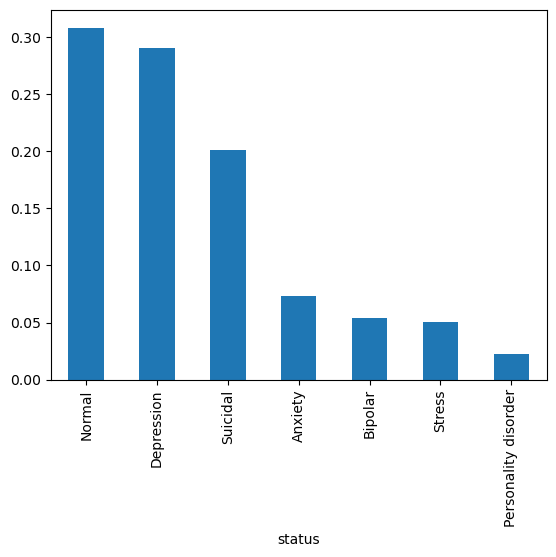

In [14]:
import pandas as pd

df = pd.read_csv("Data_M2_TP2_MKokou/Combined Data.csv")

print(df.shape)


# a. Structure and quality

df.info()
df.isna().sum()
df.duplicated().sum()

# b. Distribution class

df["status"].value_counts()
df["status"].value_counts(normalize=True).plot(kind="bar")


### Cleaning Dataset 1: removing the index column and the empty statements

In [15]:
# Preprocessing


df = df.drop(columns=["Unnamed: 0"])
df = df.dropna(subset=["statement"]).reset_index(drop=True)
print(df.shape)

(52681, 2)


### Q8 – Which representation works better with a decision tree: Bag of Words or TF-IDF?

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# a) Train / test split (before any vectorization)
X_train, X_test, y_train, y_test = train_test_split(
    df["statement"], df["status"],
    test_size=0.2, random_state=42, stratify=df["status"]
)

# b) BoW: the vocabulary is learned on the training set only
vectorizer = CountVectorizer(stop_words="english", max_features=5000)
Xtr_bow = vectorizer.fit_transform(X_train)
Xte_bow = vectorizer.transform(X_test)

# c) TF-IDF: computed from the counts, same vocabulary as the BoW
tfidf = TfidfTransformer()
Xtr_tfidf = tfidf.fit_transform(Xtr_bow)
Xte_tfidf = tfidf.transform(Xte_bow)

# d) Same decision tree for both representations
def evaluer(Xtr, Xte):
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(Xtr, y_train)
    pred = clf.predict(Xte)
    return accuracy_score(y_test, pred), f1_score(y_test, pred, average="macro"), pred

acc_bow, f1_bow, pred_bow = evaluer(Xtr_bow, Xte_bow)
acc_tfidf, f1_tfidf, pred_tfidf = evaluer(Xtr_tfidf, Xte_tfidf)

print(f"BoW    : accuracy = {acc_bow:.3f} | F1 macro = {f1_bow:.3f}")
print(f"TF-IDF : accuracy = {acc_tfidf:.3f} | F1 macro = {f1_tfidf:.3f}")

BoW    : accuracy = 0.659 | F1 macro = 0.597
TF-IDF : accuracy = 0.656 | F1 macro = 0.593


# Section 3 – Comparing four classifiers on medical abstracts (Dataset 2)

### Q9 – How accurate and how robust are the decision tree, bagging, boosting and stacking?

In [17]:
# a. Loading the medical abstracts and their labels
import pandas as pd

train = pd.read_csv("Data_M2_TP2_MKokou/medical_tc_train.csv")
test = pd.read_csv("Data_M2_TP2_MKokou/medical_tc_test.csv")
labels = pd.read_csv("Data_M2_TP2_MKokou/medical_tc_labels.csv")

print(train.shape, test.shape)
print(labels)
print(train["condition_label"].value_counts().sort_index())
print(train.isna().sum())

(11550, 2) (2888, 2)
   condition_label                   condition_name
0                1                        neoplasms
1                2        digestive system diseases
2                3          nervous system diseases
3                4          cardiovascular diseases
4                5  general pathological conditions
condition_label
1    2530
2    1195
3    1540
4    2441
5    3844
Name: count, dtype: int64
condition_label     0
medical_abstract    0
dtype: int64


In [18]:
# b. Bag-of-Words representation (vocabulary learned on the training set only)
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words="english", max_features=5000)
Xtr = vectorizer.fit_transform(train["medical_abstract"])
Xte = vectorizer.transform(test["medical_abstract"])
ytr, yte = train["condition_label"], test["condition_label"]

In [19]:
# c. The four classifiers
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                              AdaBoostClassifier, StackingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

models = {
    "Decision tree": DecisionTreeClassifier(random_state=42),
    "Bagging": BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                                 n_estimators=10, random_state=42),
    "Boosting (AdaBoost)": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3, random_state=42),
        n_estimators=30, random_state=42),
    "Stacking": StackingClassifier(
        estimators=[("dt", DecisionTreeClassifier(random_state=42)),
                    ("nb", MultinomialNB()),
                    ("rf", RandomForestClassifier(n_estimators=20, random_state=42))],
        final_estimator=LogisticRegression(max_iter=1000), cv=3),
}

In [20]:
# d. Training, evaluation and training time (Q9 and Q10)
import time
from sklearn.metrics import accuracy_score, f1_score

results = []
predictions = {}
for name, model in models.items():
    start = time.time()
    model.fit(Xtr, ytr)
    train_time = time.time() - start
    pred = model.predict(Xte)
    predictions[name] = pred
    results.append({"Model": name,
                    "Accuracy": accuracy_score(yte, pred),
                    "Macro F1": f1_score(yte, pred, average="macro"),
                    "Training time (s)": train_time})

results_df = pd.DataFrame(results).round(3)
print(results_df)

C:\Users\MAMOUDOUDIALLO\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


                 Model  Accuracy  Macro F1  Training time (s)
0        Decision tree     0.423     0.417              9.932
1              Bagging     0.473     0.469             81.158
2  Boosting (AdaBoost)     0.564     0.561              5.697
3             Stacking     0.605     0.610            143.366


In [21]:
# e. Robustness: stability of the macro F1 across 3 cross-validation folds (Q9)
from sklearn.model_selection import cross_val_score

robustness = []
for name, model in models.items():
    scores = cross_val_score(model, Xtr, ytr, cv=3, scoring="f1_macro")
    robustness.append({"Model": name,
                       "CV macro F1 (mean)": scores.mean(),
                       "CV macro F1 (std)": scores.std()})
    print(f"{name}: macro F1 = {scores.mean():.3f} ± {scores.std():.3f}")

robustness_df = pd.DataFrame(robustness).round(3)

Decision tree: macro F1 = 0.436 ± 0.006
Bagging: macro F1 = 0.502 ± 0.004


C:\Users\MAMOUDOUDIALLO\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\MAMOUDOUDIALLO\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\MAMOUDOUDIALLO\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Boosting (AdaBoost): macro F1 = 0.546 ± 0.010
Stacking: macro F1 = 0.586 ± 0.003


### Q10 – How long does each model take to train?

                 Model  Training time (s)
2  Boosting (AdaBoost)              5.697
0        Decision tree              9.932
1              Bagging             81.158
3             Stacking            143.366


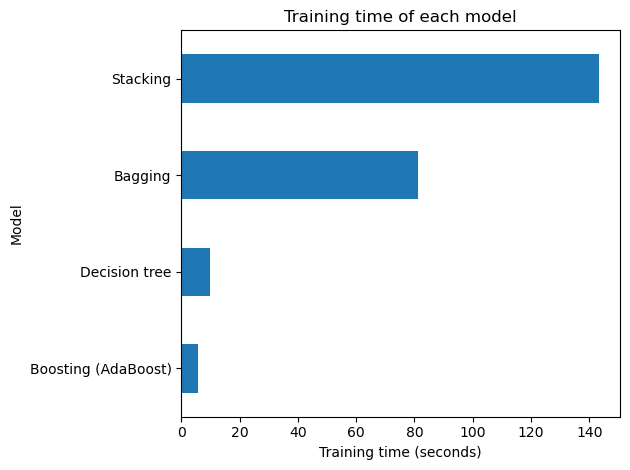

In [22]:
# Training time of each model (measured in the Q9 cell above)
# Note: the stacking time includes its internal cross-validation (cv=3).
import matplotlib.pyplot as plt

time_df = results_df[["Model", "Training time (s)"]].sort_values("Training time (s)")
print(time_df)

time_df.plot(x="Model", y="Training time (s)", kind="barh", legend=False)
plt.xlabel("Training time (seconds)")
plt.title("Training time of each model")
plt.tight_layout()
plt.show()

### Q11 – Which model is the best, and why?

                 Model  Accuracy  Macro F1  Training time (s)  \
0        Decision tree     0.423     0.417              9.932   
1              Bagging     0.473     0.469             81.158   
2  Boosting (AdaBoost)     0.564     0.561              5.697   
3             Stacking     0.605     0.610            143.366   

   CV macro F1 (mean)  CV macro F1 (std)  
0               0.436              0.006  
1               0.502              0.004  
2               0.546              0.010  
3               0.586              0.003  
                                 Decision tree  Bagging  Boosting (AdaBoost)  \
neoplasms                                0.583    0.639                0.684   
digestive system diseases                0.323    0.371                0.485   
nervous system diseases                  0.347    0.410                0.513   
cardiovascular diseases                  0.540    0.576                0.651   
general pathological conditions          0.292    0.348    

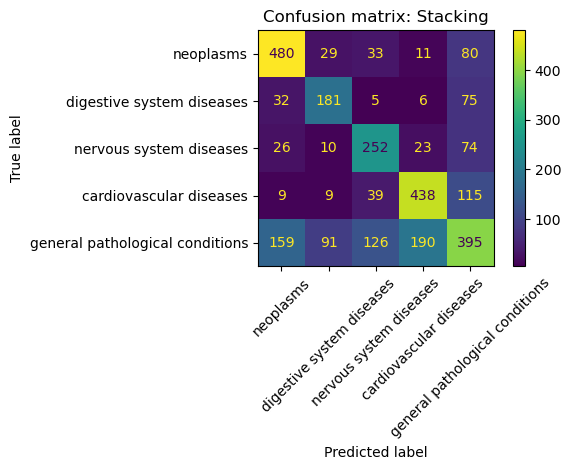

In [23]:
# Summary table: performance, robustness and cost in one place
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

summary = results_df.merge(robustness_df, on="Model")
print(summary)

# Per-class F1: which conditions are hard to predict?
classes = sorted(yte.unique())
class_names = labels.set_index("condition_label")["condition_name"]
per_class_f1 = pd.DataFrame(
    {name: f1_score(yte, pred, average=None, labels=classes)
     for name, pred in predictions.items()},
    index=[class_names[c] for c in classes]
).round(3)
print(per_class_f1)

# Confusion matrix of the best model (highest macro F1)
best_model = results_df.sort_values("Macro F1").iloc[-1]["Model"]
ConfusionMatrixDisplay.from_predictions(
    yte, predictions[best_model],
    display_labels=[class_names[c] for c in classes],
    xticks_rotation=45)
plt.title(f"Confusion matrix: {best_model}")
plt.tight_layout()
plt.show()